<a href="https://colab.research.google.com/github/carollinemelloo/ProcessamentoDeImagens/blob/main/PBL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Equipe: Ana Beatriz Nunes, Ana Luiza Souto e Carolline Mello

IMAGEM 1


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

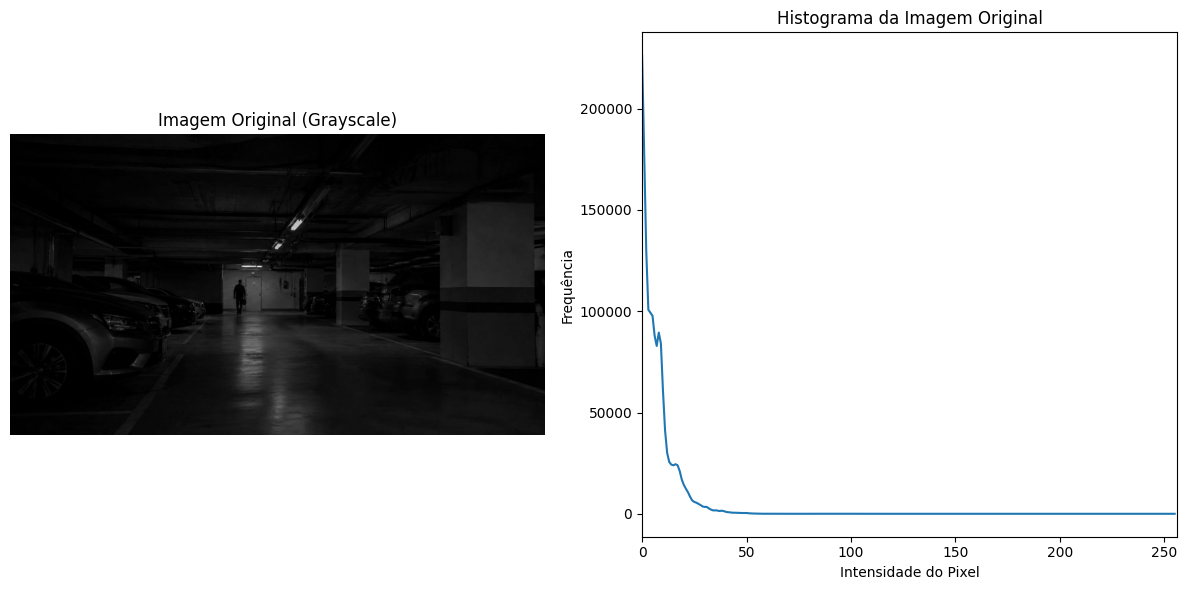

In [ ]:
image_path = '/content/imagem_01.png'
img = cv2.imread(image_path)

if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    hist = cv2.calcHist([gray_img], [0], None, [256], [0, 256])

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(gray_img, cmap='gray')
    axes[0].set_title('Imagem Original (Grayscale)')
    axes[0].axis('off')

    axes[1].plot(hist)
    axes[1].set_title('Histograma da Imagem Original')
    axes[1].set_xlabel('Intensidade do Pixel')
    axes[1].set_ylabel('Frequência')
    axes[1].set_xlim([0, 256])

    plt.tight_layout()
    plt.show()

Diagnóstico: A imagem_01.png está excessivamente escura e com baixo contraste, conforme indicado pelo histograma que mostra a maioria dos pixels concentrados em baixos níveis de intensidade.


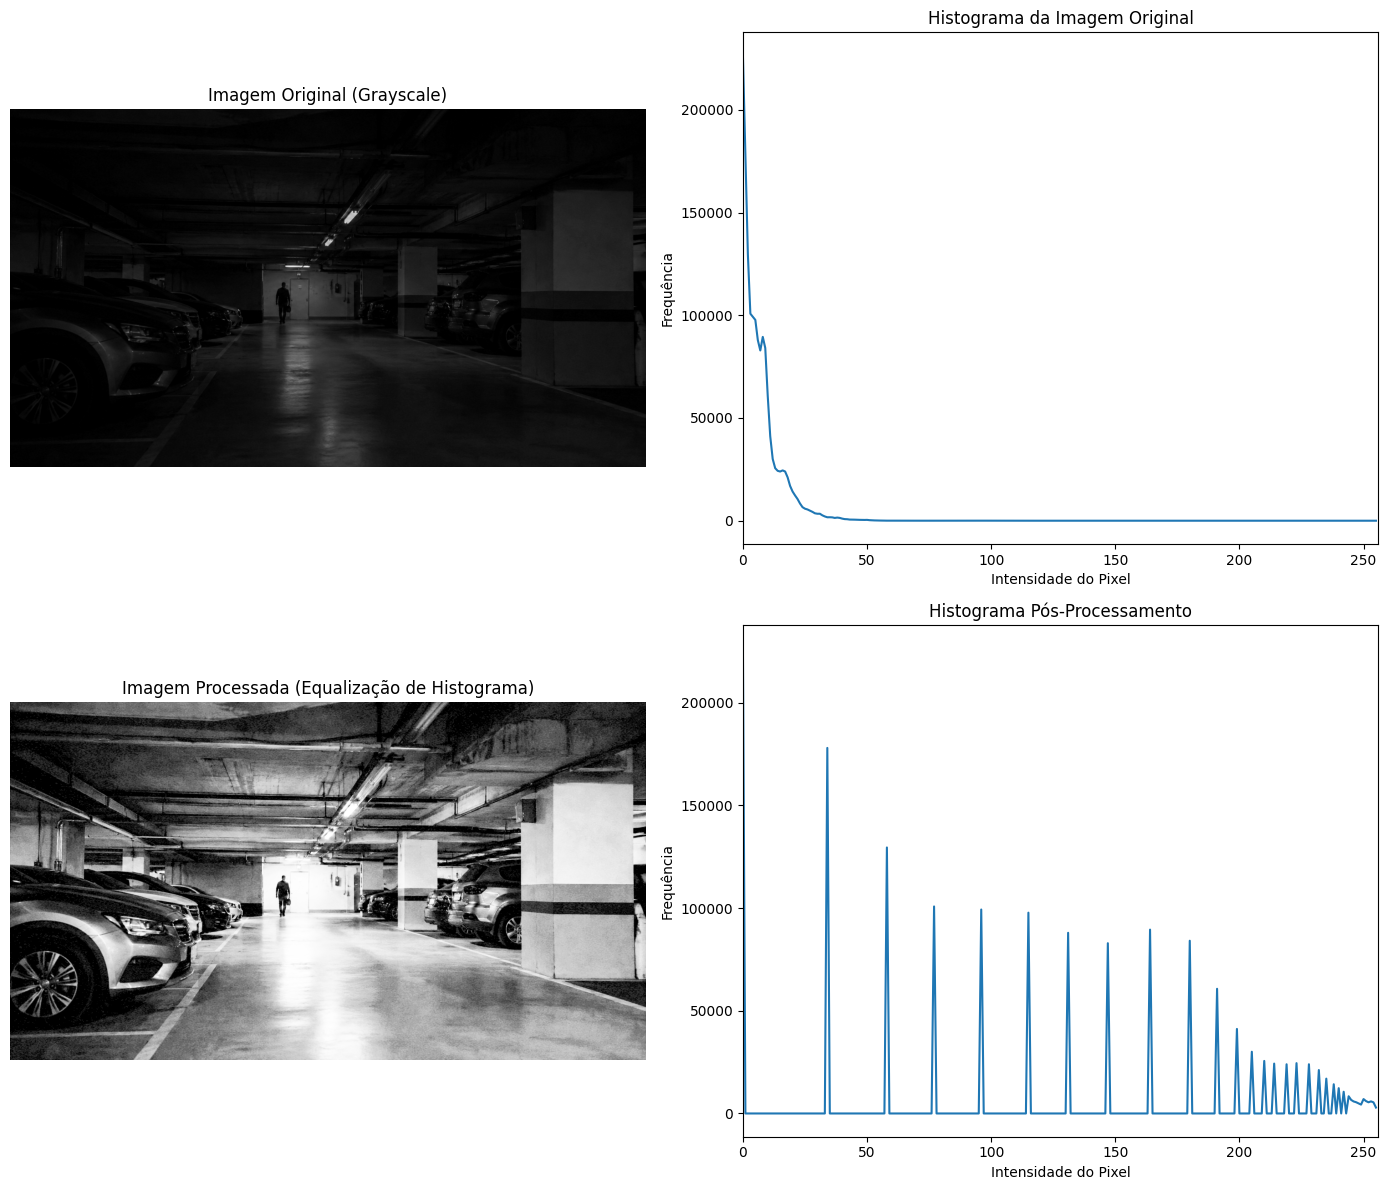

In [ ]:
img_equalized = cv2.equalizeHist(gray_img)

hist_equalized = cv2.calcHist([img_equalized], [0], None, [256], [0, 256])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].imshow(gray_img, cmap='gray')
axes[0, 0].set_title('Imagem Original (Grayscale)')
axes[0, 0].axis('off')

axes[0, 1].plot(hist)
axes[0, 1].set_title('Histograma da Imagem Original')
axes[0, 1].set_xlabel('Intensidade do Pixel')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].set_xlim([0, 256])

axes[1, 0].imshow(img_equalized, cmap='gray')
axes[1, 0].set_title('Imagem Processada (Equalização de Histograma)')
axes[1, 0].axis('off')

axes[1, 1].plot(hist_equalized)
axes[1, 1].set_title('Histograma Pós-Processamento')
axes[1, 1].set_xlabel('Intensidade do Pixel')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].set_xlim([0, 256])

plt.tight_layout()
plt.show()


Técnica/Parâmetros: Equalização de Histograma. A técnica não exige parâmetros adicionais, pois ajusta automaticamente o contraste.

Justificativa: A equalização de histograma foi escolhida para esta imagem porque seu histograma concentrado em valores baixos indica uma distribuição de intensidade limitada. Ao equalizar o histograma, as intensidades de pixel são redistribuídas de forma mais uniforme por todo o espectro, aumentando o contraste e revelando detalhes que antes estavam ocultos nas áreas escuras.

IMAGEM 2

In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
arquivo = files.upload()

Saving imagem_02.png to imagem_02.png


In [ ]:
def calc_hist(img):
    img_vetor = img.ravel()
    hist_vetor = np.zeros(256, dtype=np.int64)

    for px in img_vetor:
        hist_vetor[px] += 1

    return hist_vetor

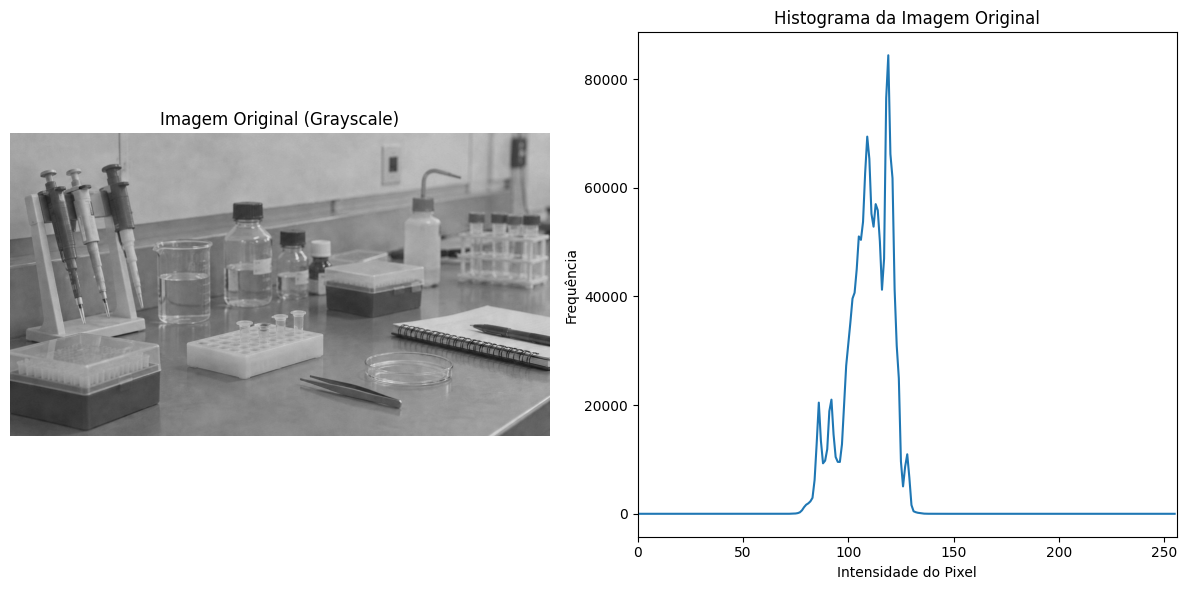

In [ ]:
img_02 = cv2.imread('imagem_02.png')

gray_img = cv2.cvtColor(img_02, cv2.COLOR_BGR2GRAY)

hist = calc_hist(gray_img)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Imagem Original (Grayscale)')
axes[0].axis('off')

axes[1].plot(hist)
axes[1].set_title('Histograma da Imagem Original')
axes[1].set_xlabel('Intensidade do Pixel')
axes[1].set_ylabel('Frequência')
axes[1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

A imagem apresenta baixo contraste, conforme indicado pelo histograma, que concentra a maior parte dos pixels em uma faixa intermediária e estreita de níveis de intensidade. Dessa forma, a imagem não utiliza adequadamente toda a faixa de tons de cinza, reduzindo a diferenciação entre regiões claras e escuras.

In [ ]:
L = 80
H = 125

imagem_contraste = np.zeros_like(gray_img)

imagem_contraste = np.clip(
    (gray_img.astype(np.float32) - L) * 255 / (H - L),
    0,
    255
).astype(np.uint8)

hist_final = calc_hist(imagem_contraste)

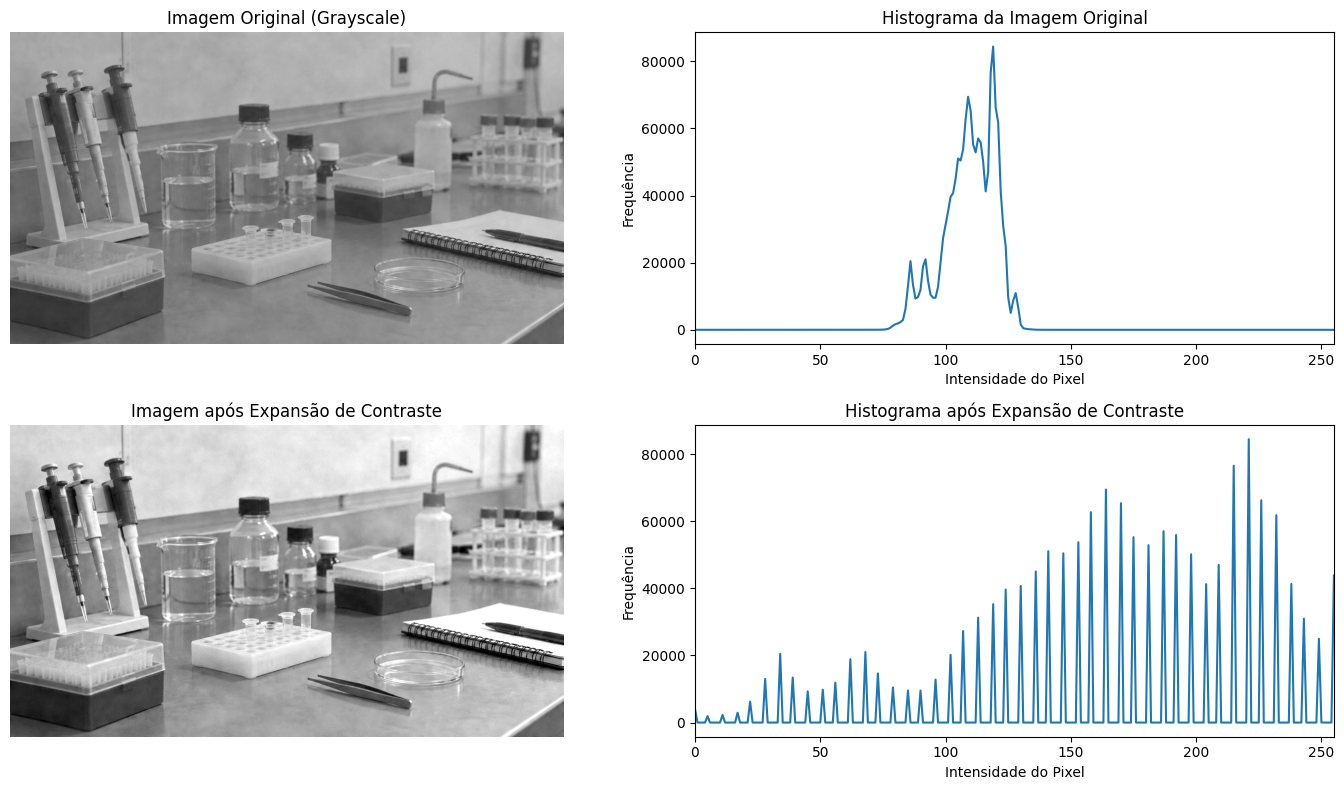

In [ ]:
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(gray_img, cmap="gray")
plt.title("Imagem Original (Grayscale)")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.plot(hist)
plt.title("Histograma da Imagem Original")
plt.xlabel("Intensidade do Pixel")
plt.ylabel("Frequência")
plt.xlim([0, 255])

plt.subplot(2, 2, 3)
plt.imshow(imagem_contraste, cmap="gray")
plt.title("Imagem após Expansão de Contraste")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.plot(hist_final)
plt.title("Histograma após Expansão de Contraste")
plt.xlabel("Intensidade do Pixel")
plt.ylabel("Frequência")
plt.xlim([0, 255])

plt.tight_layout()
plt.show()

Técnica/Parâmetros:

Foi utilizada a expansão de contraste, considerando os limites L = 80 e H = 125. A transformação redistribui os níveis de intensidade presentes nesse intervalo para uma faixa mais ampla de 0 a 255.

Justificativa:

A expansão de contraste foi escolhida porque o histograma original apresenta concentração dos pixels em uma faixa limitada de intensidades. Após a transformação, espera-se uma distribuição mais ampla dos níveis de cinza, aumentando a diferença entre regiões claras e escuras e tornando os detalhes da imagem mais perceptíveis.

IMAGEM 3

In [ ]:
arquivo = files.upload()

Saving imagem_03.png to imagem_03.png


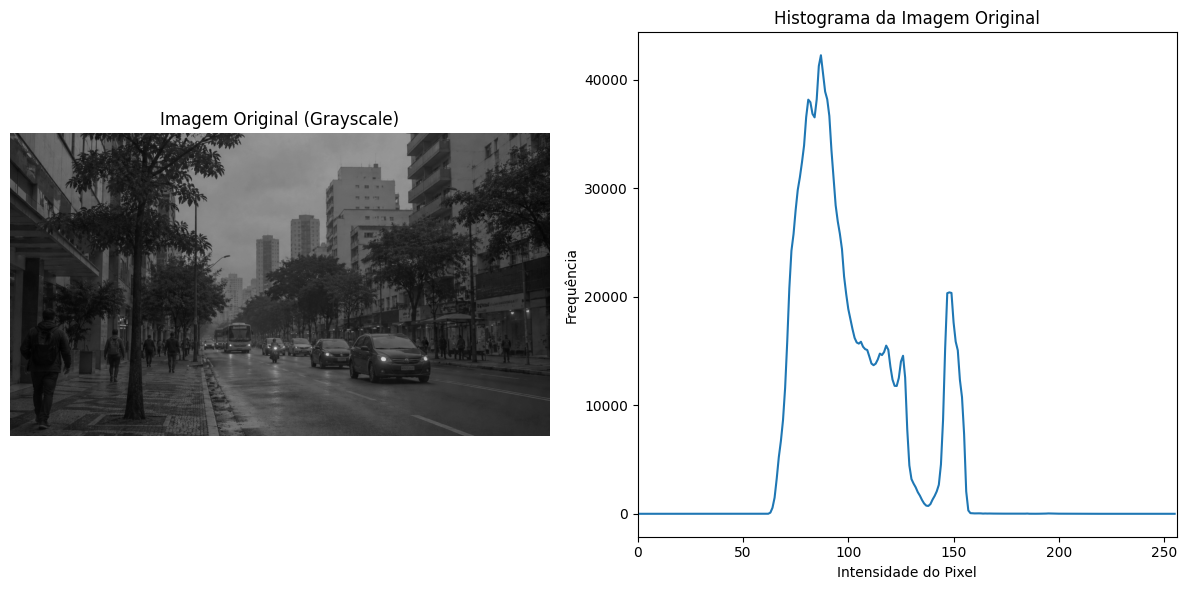

In [ ]:
img_03 = cv2.imread('imagem_03.png')

gray_img = cv2.cvtColor(img_03, cv2.COLOR_BGR2GRAY)

hist = calc_hist(gray_img)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Imagem Original (Grayscale)')
axes[0].axis('off')

axes[1].plot(hist)
axes[1].set_title('Histograma da Imagem Original')
axes[1].set_xlabel('Intensidade do Pixel')
axes[1].set_ylabel('Frequência')
axes[1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

A imagem apresenta baixa luminosidade, com predominância de pixels em níveis baixos e intermediários de intensidade. O histograma mostra uma concentração significativa dos pixels entre aproximadamente 60 e 120, indicando que a imagem está escura e necessita de clareamento.

In [ ]:
gamma = 0.6

tabela_gamma = np.array([
    ((i / 255.0) ** gamma) * 255
    for i in np.arange(0, 256)
]).astype("uint8")

imagem_corrigida = cv2.LUT(gray_img, tabela_gamma)

hist_final = calc_hist(imagem_corrigida)

Técnica/Parâmetros

Técnica: Correção Gamma

Parâmetro: γ = 0,6

Como γ < 1, a transformação aumenta as intensidades dos pixels, clareando principalmente as regiões mais escuras sem simplesmente aumentar o brilho de forma linear.

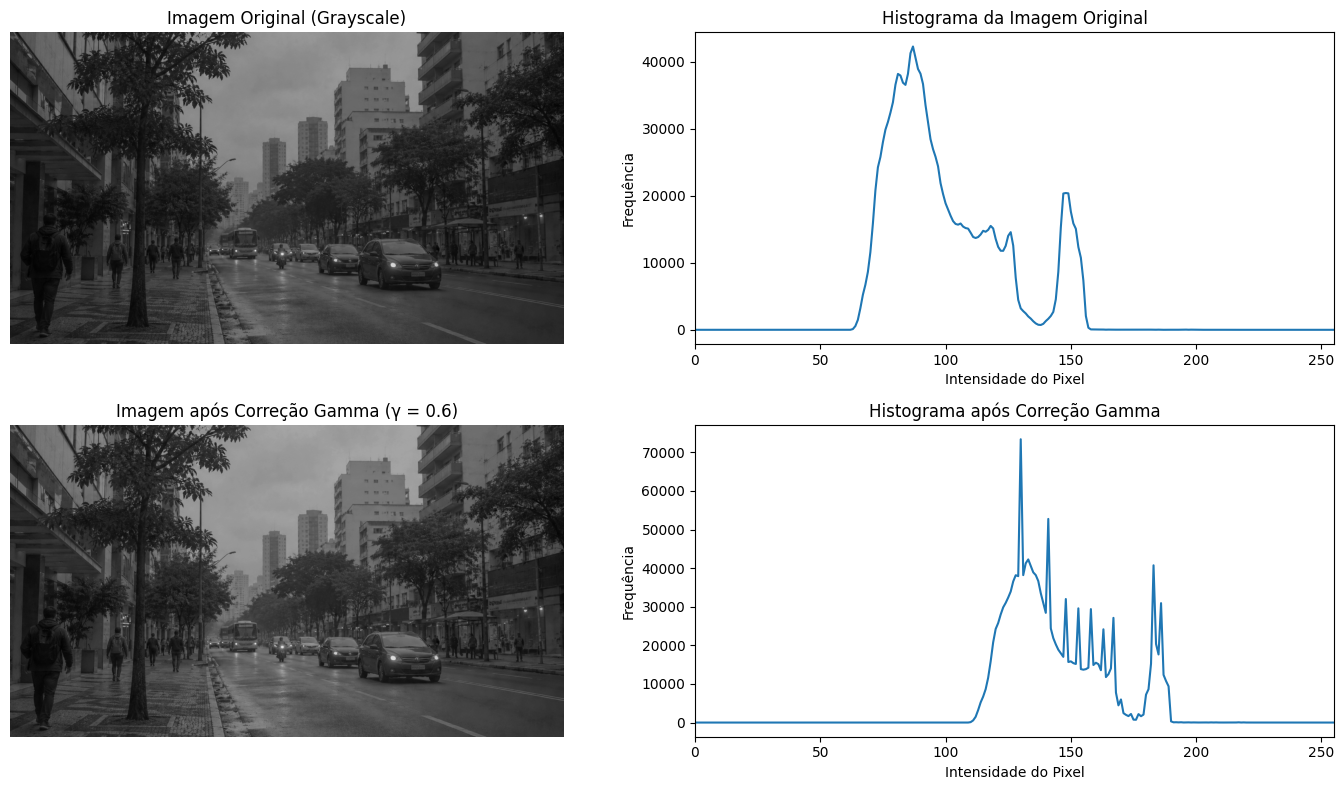

In [ ]:
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(gray_img, cmap="gray")
plt.title("Imagem Original (Grayscale)")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.plot(hist)
plt.title("Histograma da Imagem Original")
plt.xlabel("Intensidade do Pixel")
plt.ylabel("Frequência")
plt.xlim([0, 255])

plt.subplot(2, 2, 3)
plt.imshow(imagem_corrigida, cmap="gray")
plt.title(f"Imagem após Correção Gamma (γ = {gamma})")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.plot(hist_final)
plt.title("Histograma após Correção Gamma")
plt.xlabel("Intensidade do Pixel")
plt.ylabel("Frequência")
plt.xlim([0, 255])

plt.tight_layout()
plt.show()

Justificativa:

A correção Gamma foi escolhida porque a imagem apresenta baixa luminosidade, com grande concentração de pixels em intensidades baixas e intermediárias. O uso de γ = 0,6 aumenta essas intensidades, tornando as regiões escuras mais claras e permitindo visualizar melhor os detalhes da cena.

IMAGEM 4


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
arquivo = files.upload()

Saving imagem_04.png to imagem_04.png


In [ ]:
img_04 = cv2.imread('imagem_04.png')

gray_img4 = cv2.cvtColor(img_04, cv2.COLOR_BGR2GRAY)

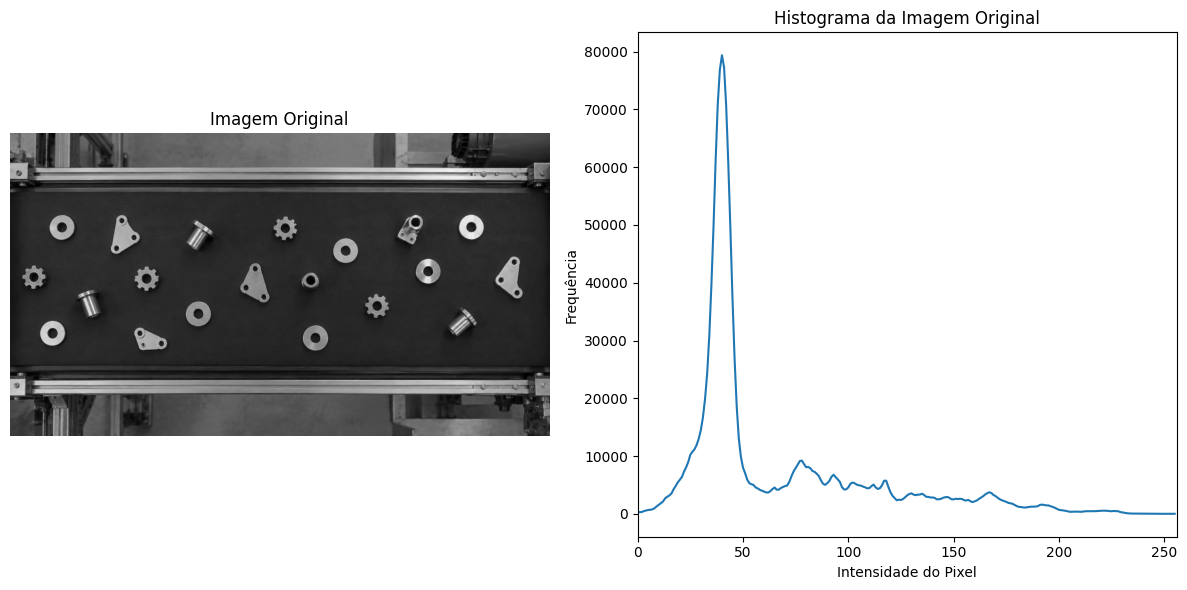

In [ ]:
hist = calc_hist(gray_img4)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(gray_img4, cmap='gray')
axes[0].set_title('Imagem Original')
axes[0].axis('off')

axes[1].plot(hist)
axes[1].set_title('Histograma da Imagem Original')
axes[1].set_xlabel('Intensidade do Pixel')
axes[1].set_ylabel('Frequência')
axes[1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

# **Diagnóstico**

O histograma apresenta uma forte concentração de pixels nas baixas intensidades, principalmente entre 40 e 50, indicando que o fundo escuro ocupa grande parte da imagem. As peças metálicas aparecem em intensidades mais elevadas, criando contraste com o fundo.

In [ ]:
def negativo_digital(img):
    return 255 - img

In [ ]:
img_negativa = negativo_digital(gray_img4)

# **Técnica / parâmetros**

Foi utilizado o **negativo digital**, que realiza a inversão das intensidades dos pixels, sem a necessidade de definir um parâmetro

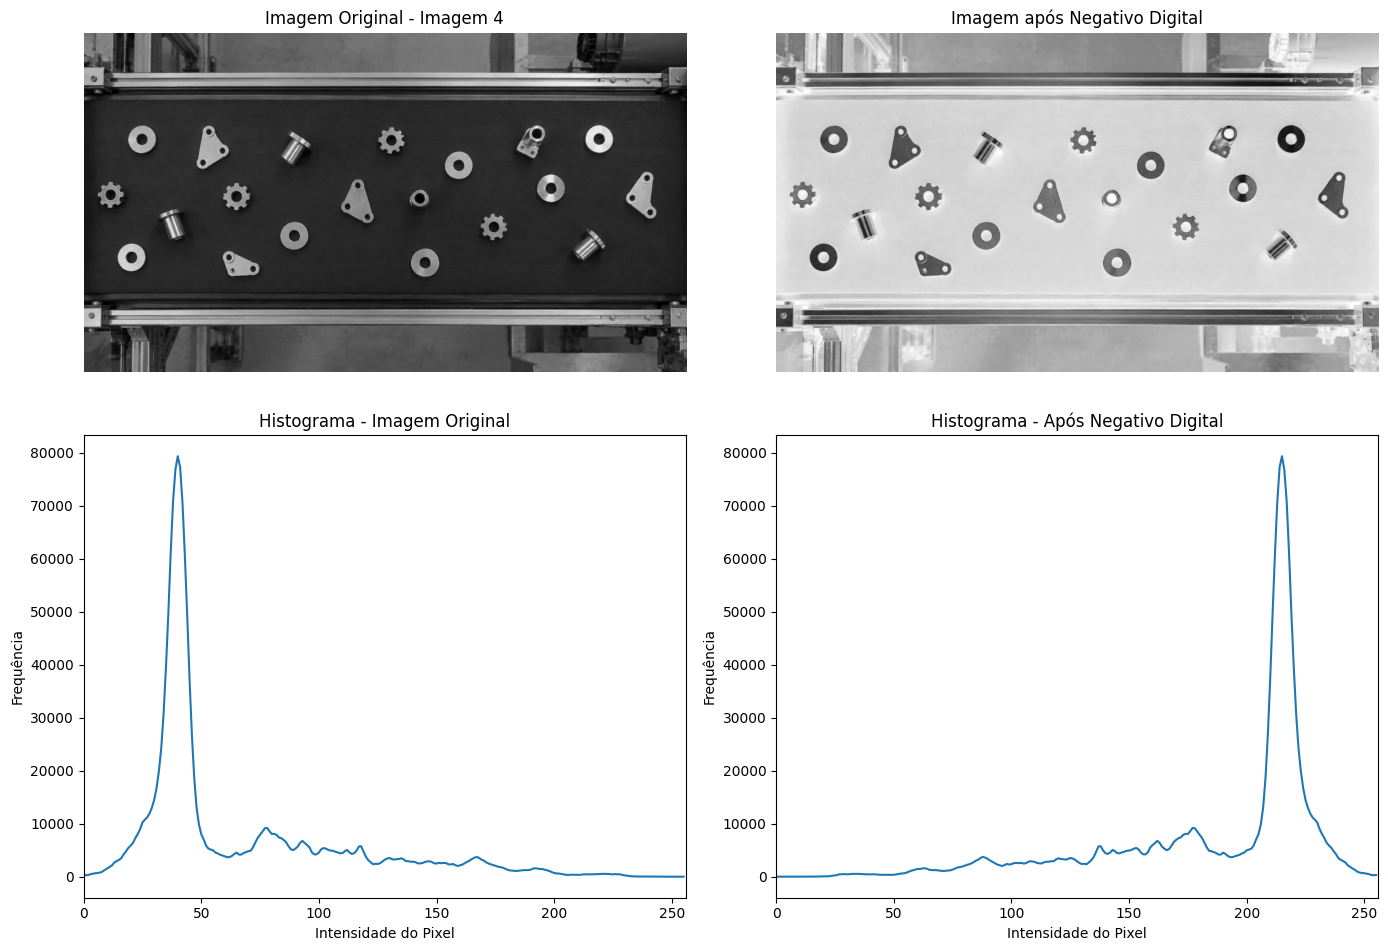

In [ ]:
hist_original = calc_hist(gray_img4)

hist_negativa = calc_hist(img_negativa)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(gray_img4, cmap='gray')
axes[0, 0].set_title('Imagem Original - Imagem 4')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_negativa, cmap='gray')
axes[0, 1].set_title('Imagem após Negativo Digital')
axes[0, 1].axis('off')

axes[1, 0].plot(hist_original)
axes[1, 0].set_title('Histograma - Imagem Original')
axes[1, 0].set_xlabel('Intensidade do Pixel')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].set_xlim(0, 256)

axes[1, 1].plot(hist_negativa)
axes[1, 1].set_title('Histograma - Após Negativo Digital')
axes[1, 1].set_xlabel('Intensidade do Pixel')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].set_xlim(0, 256)

plt.tight_layout()
plt.show()

# **Justificativa**

O negativo digital foi escolhido porque a imagem apresenta uma forte predominância de tons escuros, fazendo com que os detalhes das peças se destaquem apenas em pequenas regiões mais claras. Nesse caso, a inversão permite alterar a relação visual entre fundo e objetos, tornando os elementos de interesse mais evidentes e proporcionando uma representação alternativa da mesma cena.


IMAGEM 5

In [ ]:
arquivo = files.upload()

Saving imagem_05.png to imagem_05.png


In [ ]:
img_05 = cv2.imread('imagem_05.png')
gray_img5 = cv2.cvtColor(img_05, cv2.COLOR_BGR2GRAY)

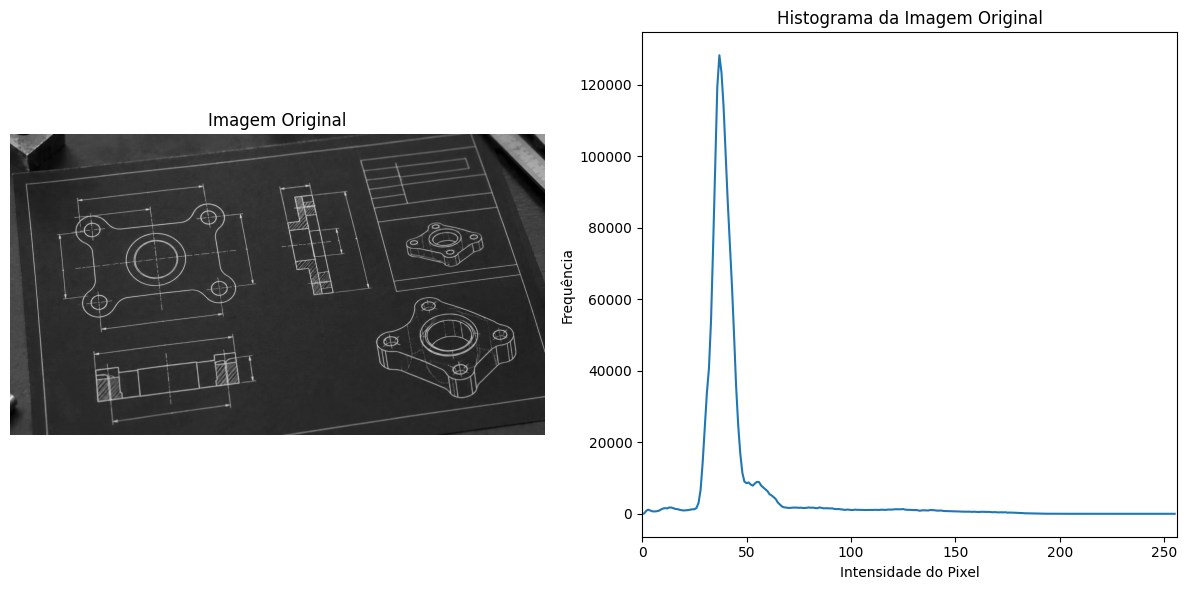

In [ ]:
hist = calc_hist(gray_img5)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(gray_img5, cmap='gray')
axes[0].set_title('Imagem Original')
axes[0].axis('off')

axes[1].plot(hist)
axes[1].set_title('Histograma da Imagem Original')
axes[1].set_xlabel('Intensidade do Pixel')
axes[1].set_ylabel('Frequência')
axes[1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

# **Diagnóstico**

O histograma apresenta uma grande concentração de pixels nas baixas intensidades, principalmente entre 30 e 50, indicando que o fundo escuro representa a maior parte da imagem. Os desenhos técnicos são formados por linhas mais claras, apresentando intensidades superiores às do fundo.

In [ ]:
def limiarizar(img, T):
    _, img_limiar = cv2.threshold(
        img,
        T,
        255,
        cv2.THRESH_BINARY
    )
    return img_limiar

In [ ]:
T = 70

gray_img5_limiar = limiarizar(gray_img5, T)

# **Técnica / parâmetro**

Foi utilizada a **limiarização binária**, com T = 70.

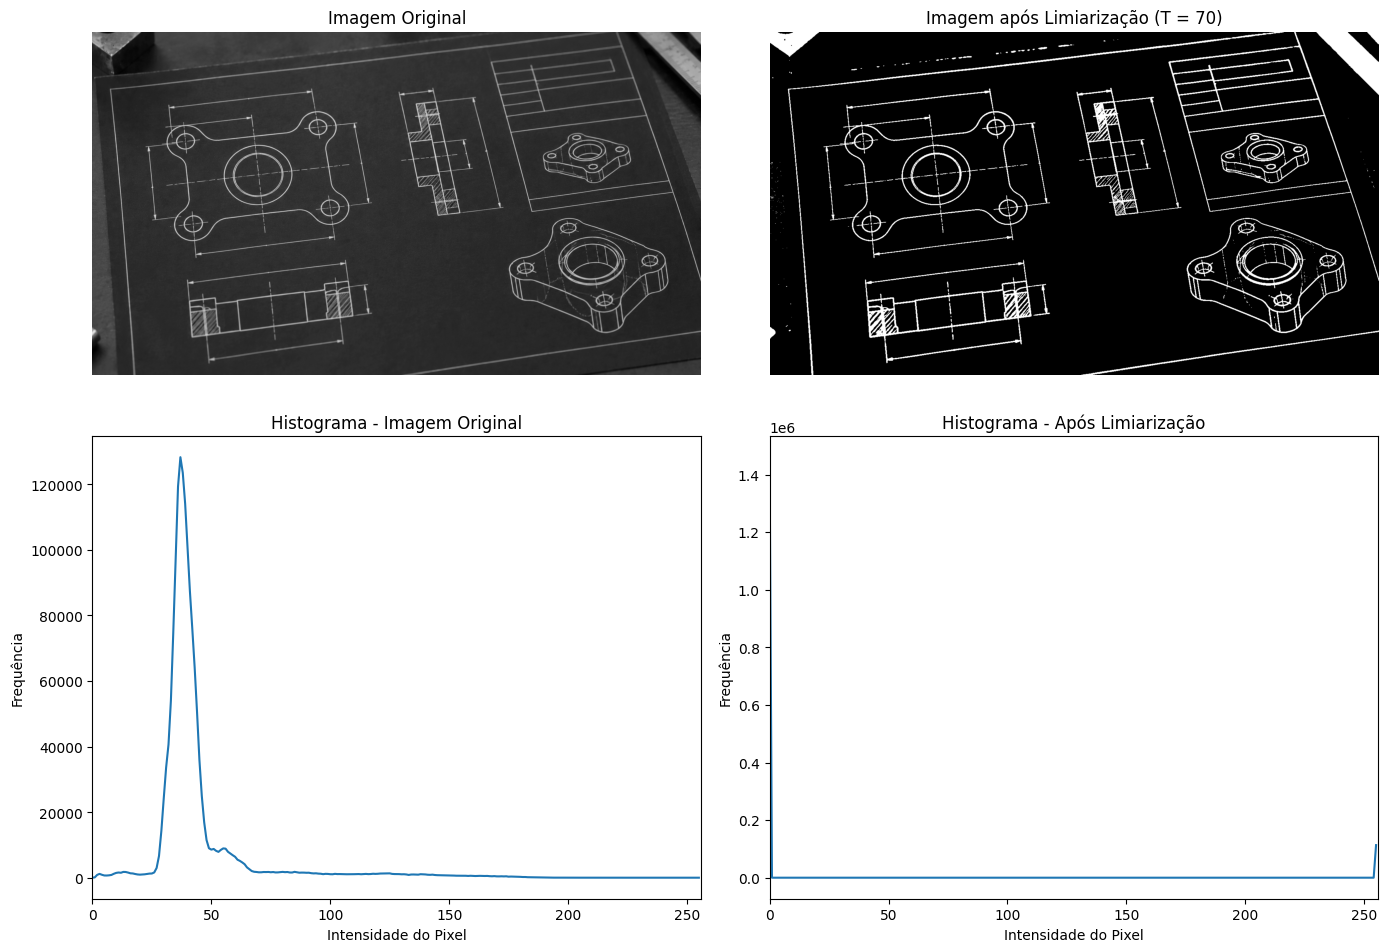

In [ ]:
hist_original = calc_hist(gray_img5)
hist_limiar = calc_hist(gray_img5_limiar)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(gray_img5, cmap='gray')
axes[0, 0].set_title('Imagem Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(gray_img5_limiar, cmap='gray')
axes[0, 1].set_title(f'Imagem após Limiarização (T = {T})')
axes[0, 1].axis('off')

axes[1, 0].plot(hist_original)
axes[1, 0].set_title('Histograma - Imagem Original')
axes[1, 0].set_xlabel('Intensidade do Pixel')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].set_xlim(0, 256)

axes[1, 1].plot(hist_limiar)
axes[1, 1].set_title('Histograma - Após Limiarização')
axes[1, 1].set_xlabel('Intensidade do Pixel')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].set_xlim(0, 256)

plt.tight_layout()
plt.show()

# **Justificativa**

A limiarização foi escolhida porque existe uma diferença de intensidade entre o fundo escuro e os traços claros dos desenhos técnicos. Com o limiar T = 70, os pixels abaixo desse valor são classificados como pretos e os pixels acima como brancos, destacando os desenhos e facilitando a identificação de suas formas e contornos.